<a href="https://colab.research.google.com/github/JhuertaAhu/TripleTen-Proyects/blob/main/Sprint_6_Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎮 Sprint 6 — Proyecto Integrado: Análisis de Ventas de Videojuegos

**Contexto:** Trabajamos para la tienda online **Ice**, que vende videojuegos en todo el mundo. El objetivo es identificar patrones que determinen si un juego tiene éxito, para así detectar proyectos prometedores y planificar campañas publicitarias para **2017**.

**Dataset:** Datos históricos de ventas de videojuegos hasta 2016, incluyendo reseñas de usuarios y expertos, géneros, plataformas y clasificaciones ESRB.

---

## Paso 1: Apertura del archivo y exploración general

In [3]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Suprimir advertencias innecesarias
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Carga del dataset
df = pd.read_csv('games.csv')

# Vista general
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head(10)

Dimensiones del dataset: 16715 filas x 11 columnas


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [5]:
# Información general: tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [6]:
# Estadísticas descriptivas de las columnas numéricas
df.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


In [7]:
# Conteo de valores ausentes por columna
print('Valores ausentes por columna:')
print(df.isnull().sum())

Valores ausentes por columna:
Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64


**Observaciones iniciales:**
- El dataset contiene 16,715 registros con 11 columnas.
- Las columnas `Critic_Score`, `User_Score` y `Rating` presentan una cantidad significativa de valores ausentes.
- `Year_of_Release` también tiene 269 valores nulos.
- `User_Score` está almacenada como texto (`object`), lo que indica que contiene valores no numéricos como `'tbd'`.

---

## Paso 2: Preparación de los datos

### 2.1 Renombrar columnas a minúsculas

In [8]:
# Convertir nombres de columnas a minúsculas para uniformidad
df.columns = df.columns.str.lower()
print('Columnas renombradas:')
print(df.columns.tolist())

Columnas renombradas:
['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']


### 2.2 Conversión de tipos de datos

In [9]:
# --- year_of_release ---
# Actualmente es float64 debido a valores nulos. Lo convertimos a Int64 (entero con soporte de NaN).
df['year_of_release'] = df['year_of_release'].astype('Int64')

# --- user_score ---
# Contiene valores 'tbd' (to be determined) que impiden la conversión directa.
# Reemplazamos 'tbd' con NaN y luego convertimos a float.
df['user_score'] = df['user_score'].replace('tbd', np.nan)
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

# --- critic_score ---
# Ya es float64; no requiere conversión.

print('Tipos de datos después de la conversión:')
print(df.dtypes)

Tipos de datos después de la conversión:
name                object
platform            object
year_of_release      Int64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score         float64
rating              object
dtype: object


**Justificación de conversiones:**

- **`year_of_release` → Int64:** El año es un dato entero. Era `float64` únicamente porque pandas no soporta enteros nulos nativos con `int64`, por eso se usa el tipo `Int64` (nullable integer).
- **`user_score` → float64:** Esta columna era de tipo `object` porque contenía cadenas de texto, incluyendo el valor `'tbd'` ("to be determined"). Se reemplazaron los `'tbd'` con `NaN` antes de convertir a numérico, ya que no representan una puntuación válida.

### 2.3 Tratamiento de valores ausentes

In [10]:
# Estado de valores ausentes después de las conversiones
print('Valores ausentes actualizados:')
print(df.isnull().sum())
print()
print(f'Total de registros TBD convertidos a NaN en user_score: {df["user_score"].isna().sum()}')

Valores ausentes actualizados:
name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

Total de registros TBD convertidos a NaN en user_score: 9125


**Decisiones sobre valores ausentes:**

| Columna | Ausentes | Decisión | Justificación |
|---|---|---|---|
| `name` | 2 | Dejar como NaN | Filas no identificables, impacto mínimo |
| `year_of_release` | 269 | Dejar como NaN | No podemos inferir el año con certeza; se excluirán del análisis temporal |
| `genre` | 2 | Dejar como NaN | Sin información suficiente para imputar |
| `critic_score` | ~8,578 | Dejar como NaN | Muchos juegos antiguos no tienen reseñas de críticos; no imputar evita sesgo |
| `user_score` | ~9,125 | Dejar como NaN | Incluye los `'tbd'` originales; misma razón que `critic_score` |
| `rating` | ~6,766 | Dejar como NaN | La clasificación ESRB no siempre fue aplicada, especialmente en juegos antiguos |

**¿Por qué están ausentes?**
- Los juegos más antiguos (décadas de 1980-1990) no tenían sistemas de clasificación ni plataformas de reseñas digitales como Metacritic.
- El sistema ESRB comenzó en 1994, por lo que juegos anteriores a esa fecha no tienen `rating`.
- Los valores `'tbd'` en `user_score` indican juegos que aún no tenían suficientes votos al momento de la recopilación de datos.

### 2.4 Calcular ventas totales

In [11]:
# Suma de ventas en todas las regiones (en millones de USD)
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

print('Vista previa con la nueva columna total_sales:')
df[['name', 'platform', 'year_of_release', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].head(10)

Vista previa con la nueva columna total_sales:


,name,platform,year_of_release,na_sales,eu_sales,jp_sales,other_sales,total_sales
0,Wii Sports,Wii,2006,41.36,28.96,3.77,8.45,82.54
1,Super Mario Bros.,NES,1985,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008,15.68,12.76,3.79,3.29,35.52
3,Wii Sports Resort,Wii,2009,15.61,10.93,3.28,2.95,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,11.27,8.89,10.22,1.00,31.38
5,Tetris,GB,1989,23.20,2.26,4.22,0.58,30.26
6,New Super Mario Bros.,DS,2006,11.28,9.14,6.50,2.88,29.80
7,Wii Play,Wii,2006,13.96,9.18,2.93,2.84,28.91
8,New Super Mario Bros. Wii,Wii,2009,14.44,6.94,4.70,2.24,28.32
9,Duck Hunt,NES,1984,26.93,0.63,0.28,0.47,28.31


---
## Paso 3: Análisis de los datos

### 3.1 Juegos lanzados por año

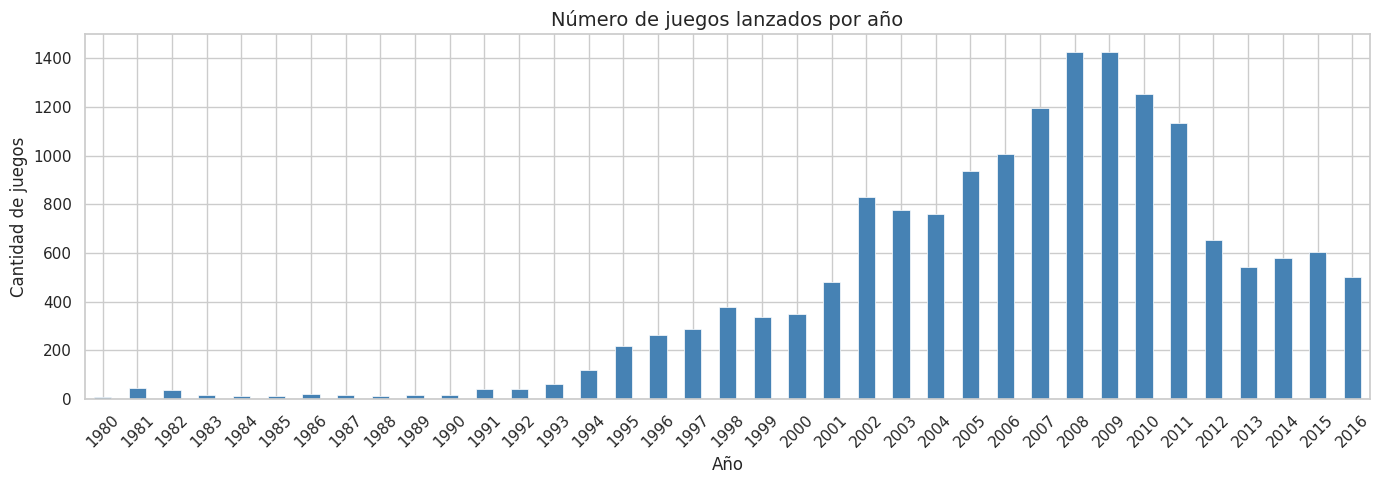


Juegos por año (ordenado):
year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
dtype: int64


In [12]:
games_per_year = df.dropna(subset=['year_of_release']).groupby('year_of_release').size()

fig, ax = plt.subplots(figsize=(14, 5))
games_per_year.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Número de juegos lanzados por año')
ax.set_xlabel('Año')
ax.set_ylabel('Cantidad de juegos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('\nJuegos por año (ordenado):')
print(games_per_year.sort_index())

**Observaciones:**
- Los datos de antes de **2000** son escasos y poco representativos de la industria moderna.
- El pico de lanzamientos se produce entre **2007 y 2010**, periodo de gran auge de la industria.
- Los datos de **2016** probablemente estén incompletos, ya que el dataset fue recopilado antes de que terminara ese año.
- Para el análisis de campaña 2017, nos enfocaremos en datos **recientes y representativos**.

### 3.2 Ventas por plataforma y ciclo de vida

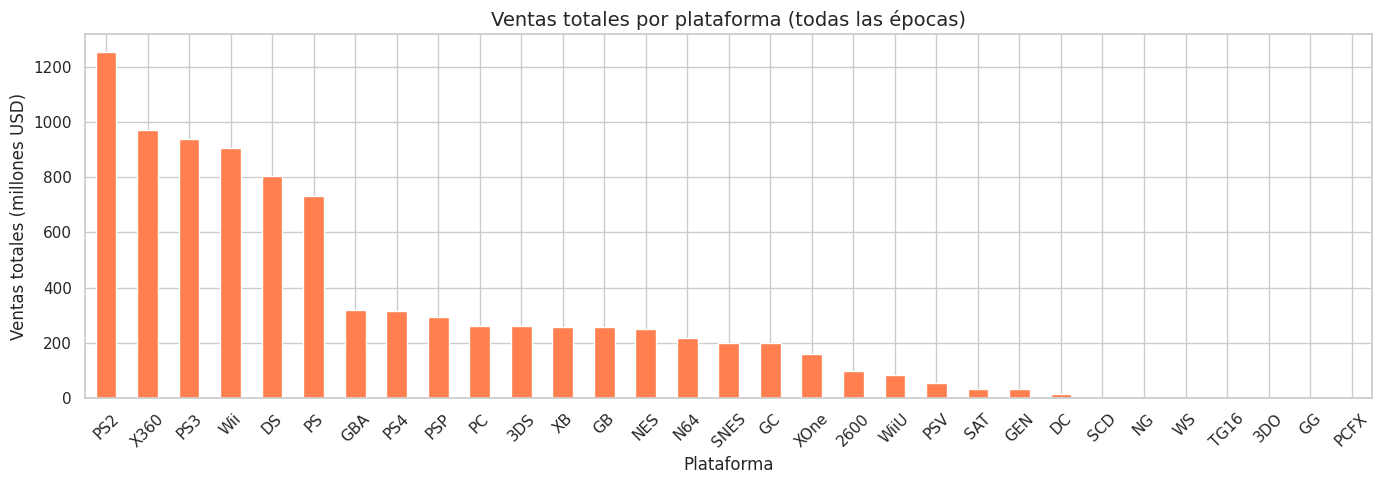

In [13]:
# Ventas totales por plataforma
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
platform_sales.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Ventas totales por plataforma (todas las épocas)')
ax.set_xlabel('Plataforma')
ax.set_ylabel('Ventas totales (millones USD)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

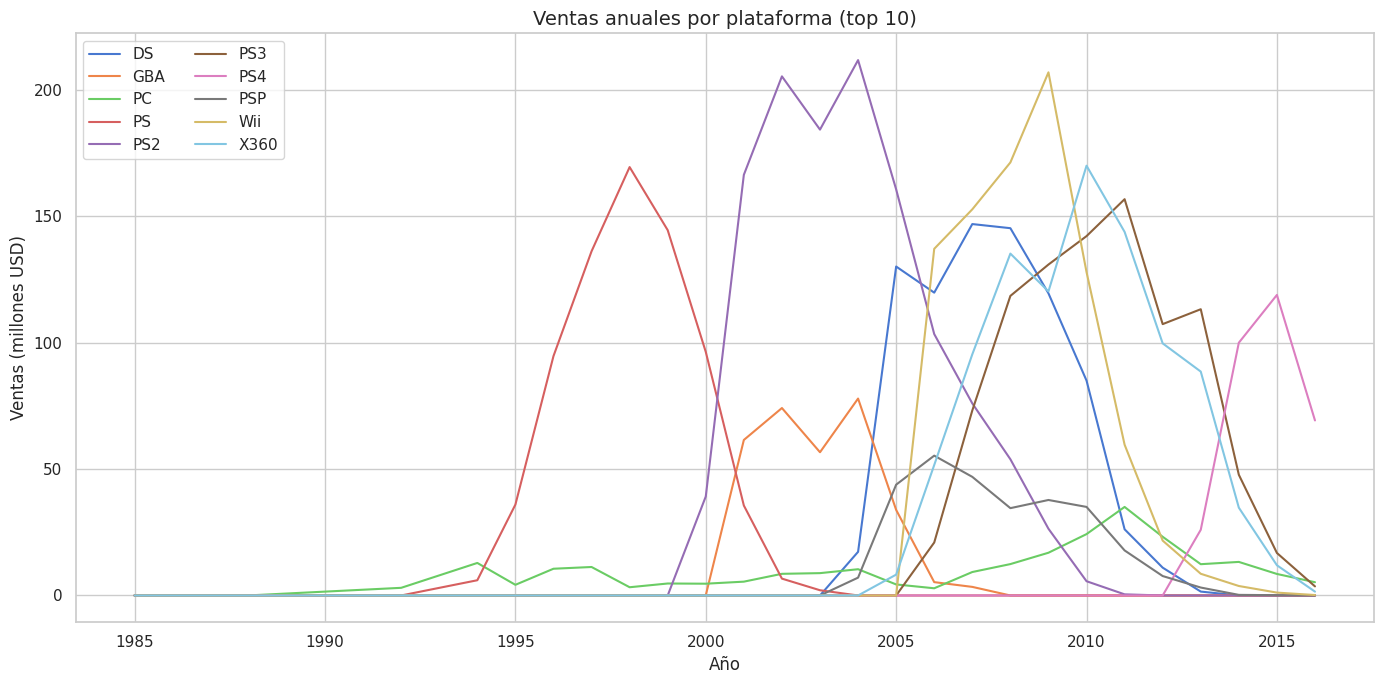

In [14]:
# Evolución de ventas de las principales plataformas por año
top_platforms = platform_sales.head(10).index.tolist()

df_top = df[df['platform'].isin(top_platforms)].dropna(subset=['year_of_release'])
pivot = df_top.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack().fillna(0)

pivot.plot(figsize=(14, 7))
plt.title('Ventas anuales por plataforma (top 10)')
plt.xlabel('Año')
plt.ylabel('Ventas (millones USD)')
plt.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

**Observaciones sobre el ciclo de vida de las plataformas:**
- Las plataformas tienen ciclos de vida de aproximadamente **5 a 7 años** de actividad relevante.
- Plataformas como PS2, Wii y X360 dominaron en su época pero sus ventas cayeron a cero gradualmente.
- Las plataformas modernas con actividad en 2016 son: **PS4, XOne, 3DS, PS3 y X360** (esta última en declive).

### 3.3 Selección del período relevante

In [15]:
# Nos quedamos con datos de 2012 en adelante para el análisis de campaña 2017.
# Esto nos da 5 años de datos recientes, suficiente para capturar tendencias actuales.
df_recent = df[df['year_of_release'] >= 2012].copy()

print(f'Registros en el período 2012-2016: {len(df_recent)}')
print(f'Distribución por año:')
print(df_recent['year_of_release'].value_counts().sort_index())

Registros en el período 2012-2016: 2886
Distribución por año:
year_of_release
2012    653
2013    544
2014    581
2015    606
2016    502
Name: count, dtype: Int64


**Justificación del período 2012-2016:**
- Dado que los ciclos de vida de las plataformas son de ~5-7 años, los datos de 2012 a 2016 capturan la generación de consolas actualmente vigente (PS4, XOne, Wii U).
- Los datos anteriores a 2012 corresponden en gran parte a plataformas ya discontinuadas (PS2, Wii, X360 en declive), que no son relevantes para planificar una campaña 2017.
- Este período ofrece un balance entre suficiente volumen de datos y relevancia temporal.

### 3.4 Plataformas líderes en el período reciente

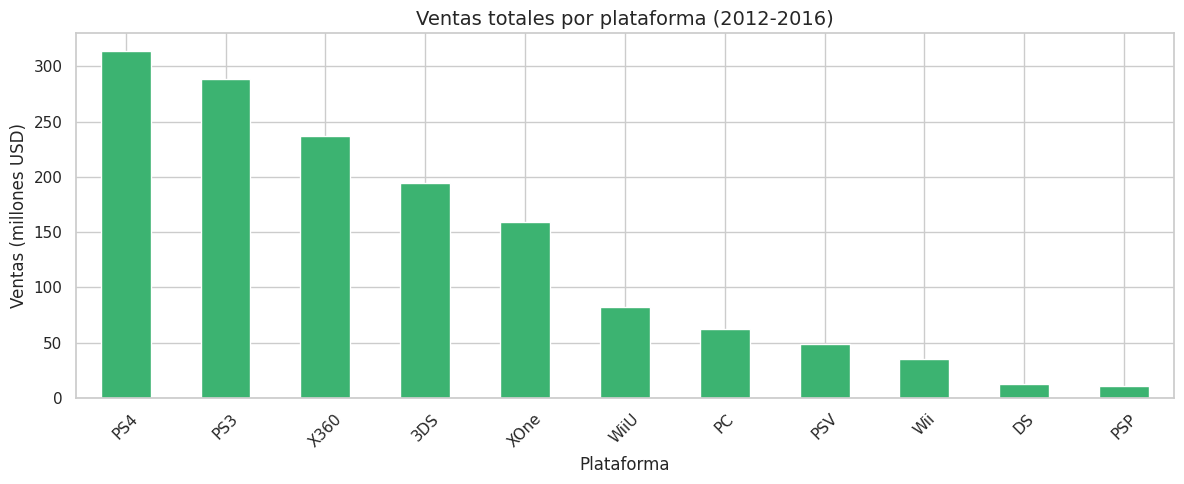

platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
PSP      11.19
Name: total_sales, dtype: float64


In [16]:
recent_platform_sales = df_recent.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
recent_platform_sales.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Ventas totales por plataforma (2012-2016)')
ax.set_xlabel('Plataforma')
ax.set_ylabel('Ventas (millones USD)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(recent_platform_sales)

**Plataformas potencialmente rentables para 2017:**
- **PS4:** Líder claro del período reciente, en pleno crecimiento.
- **XOne:** Segunda en ventas recientes, estable.
- **3DS:** Fuerte en JP y NA para videojuegos portátiles.
- **PS3 / X360:** En declive pero con base instalada grande; ventas residuales.

Las plataformas a priorizar para la campaña 2017 son **PS4 y XOne** por su trayectoria ascendente.

### 3.5 Diagrama de caja: ventas globales por plataforma

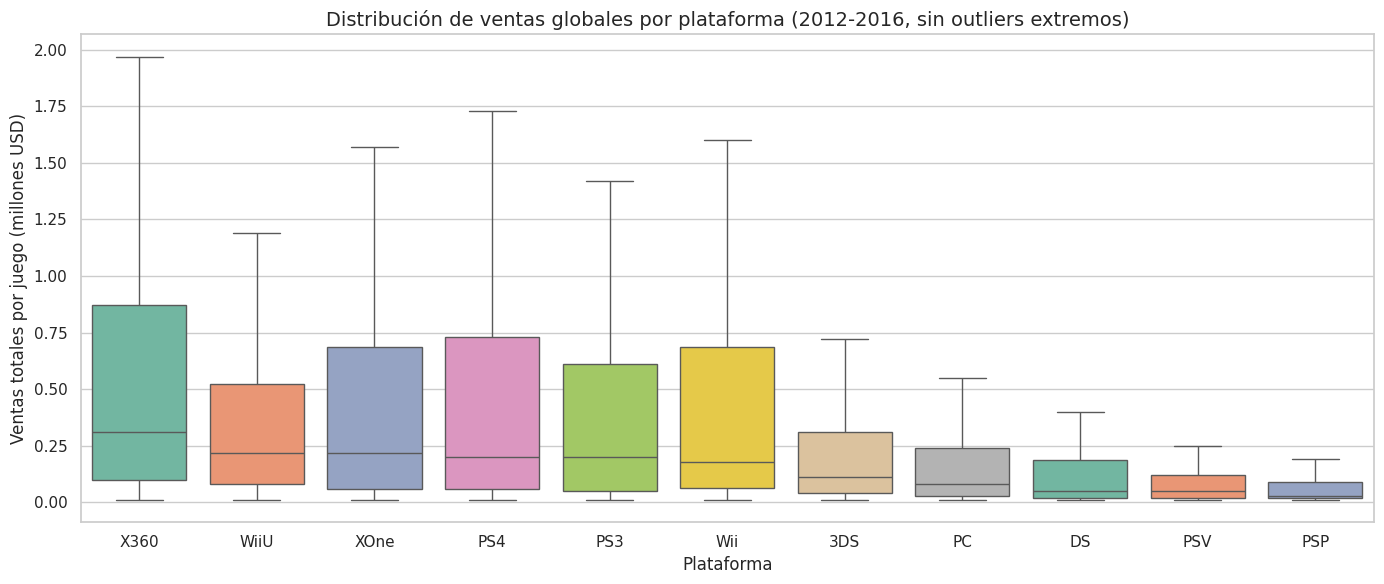

In [17]:
# Filtramos plataformas con al menos 30 juegos en el período reciente para mayor representatividad
plat_counts = df_recent['platform'].value_counts()
plats_valid = plat_counts[plat_counts >= 30].index.tolist()
df_box = df_recent[df_recent['platform'].isin(plats_valid)]

# Ordenar por mediana
order = df_box.groupby('platform')['total_sales'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=df_box, x='platform', y='total_sales',
    order=order, ax=ax,
    showfliers=False,  # Ocultamos outliers extremos para mejor visualización
    palette='Set2'
)
ax.set_title('Distribución de ventas globales por plataforma (2012-2016, sin outliers extremos)')
ax.set_xlabel('Plataforma')
ax.set_ylabel('Ventas totales por juego (millones USD)')
plt.tight_layout()
plt.show()

**Hallazgos del diagrama de caja:**
- Las diferencias entre plataformas **son significativas**: PS4 y XOne tienen medianas más altas que plataformas legacy como X360 o PS3.
- Todas las plataformas muestran una distribución sesgada a la derecha: la mayoría de los juegos vende poco, pero unos pocos venden muchísimo.
- La gran dispersión dentro de cada plataforma indica que **el género y la calidad del juego** son factores determinantes más allá de la plataforma.

### 3.6 Efecto de las reseñas en las ventas (PS4)

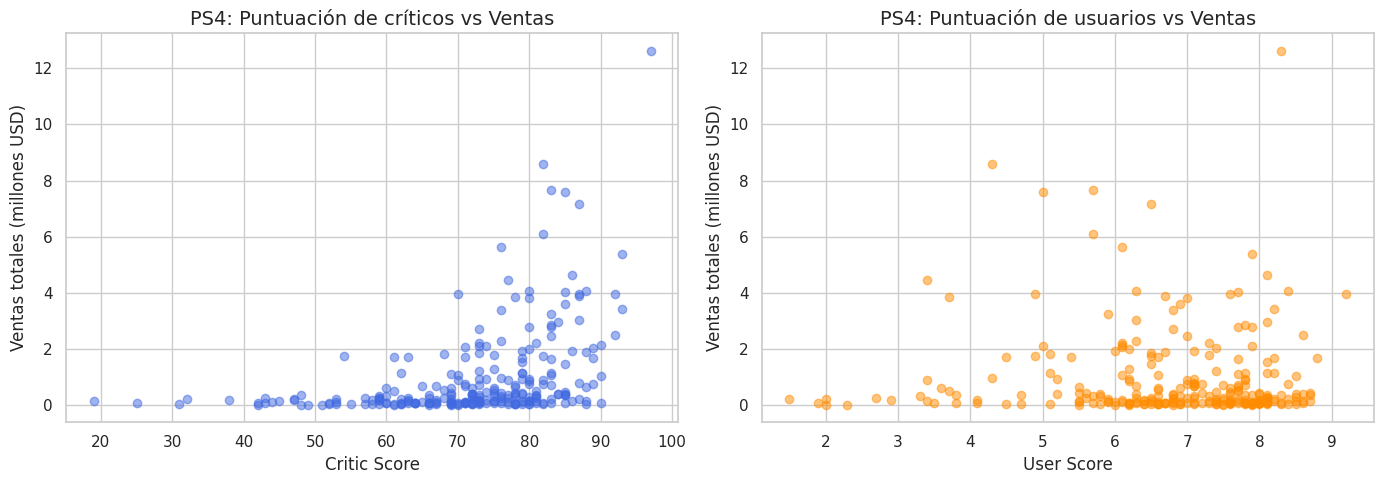

Correlación Critic Score vs Ventas (PS4): 0.406
Correlación User Score vs Ventas (PS4):   -0.034


In [18]:
# Analizamos PS4 como plataforma representativa del período actual
df_ps4 = df_recent[df_recent['platform'] == 'PS4'].dropna(subset=['critic_score', 'user_score', 'total_sales'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reseñas de críticos vs ventas
axes[0].scatter(df_ps4['critic_score'], df_ps4['total_sales'], alpha=0.5, color='royalblue')
axes[0].set_title('PS4: Puntuación de críticos vs Ventas')
axes[0].set_xlabel('Critic Score')
axes[0].set_ylabel('Ventas totales (millones USD)')

# Reseñas de usuarios vs ventas
axes[1].scatter(df_ps4['user_score'], df_ps4['total_sales'], alpha=0.5, color='darkorange')
axes[1].set_title('PS4: Puntuación de usuarios vs Ventas')
axes[1].set_xlabel('User Score')
axes[1].set_ylabel('Ventas totales (millones USD)')

plt.tight_layout()
plt.show()

# Correlaciones
corr_critic = df_ps4['critic_score'].corr(df_ps4['total_sales'])
corr_user = df_ps4['user_score'].corr(df_ps4['total_sales'])

print(f'Correlación Critic Score vs Ventas (PS4): {corr_critic:.3f}')
print(f'Correlación User Score vs Ventas (PS4):   {corr_user:.3f}')

**Conclusiones sobre el efecto de las reseñas:**
- La **correlación entre la puntuación de críticos y las ventas** es positiva y moderada, lo que sugiere que los juegos mejor evaluados tienden a vender más, aunque no es una relación determinante.
- La **correlación entre la puntuación de usuarios y las ventas** es más débil, posiblemente porque los usuarios puntúan el juego después de comprarlo, no antes.
- En ningún caso la reseña es el único factor; existen juegos de puntuación alta con ventas bajas y viceversa (títulos de nicho vs. franquicias masivas).

### 3.7 Comparación entre plataformas para los mismos juegos

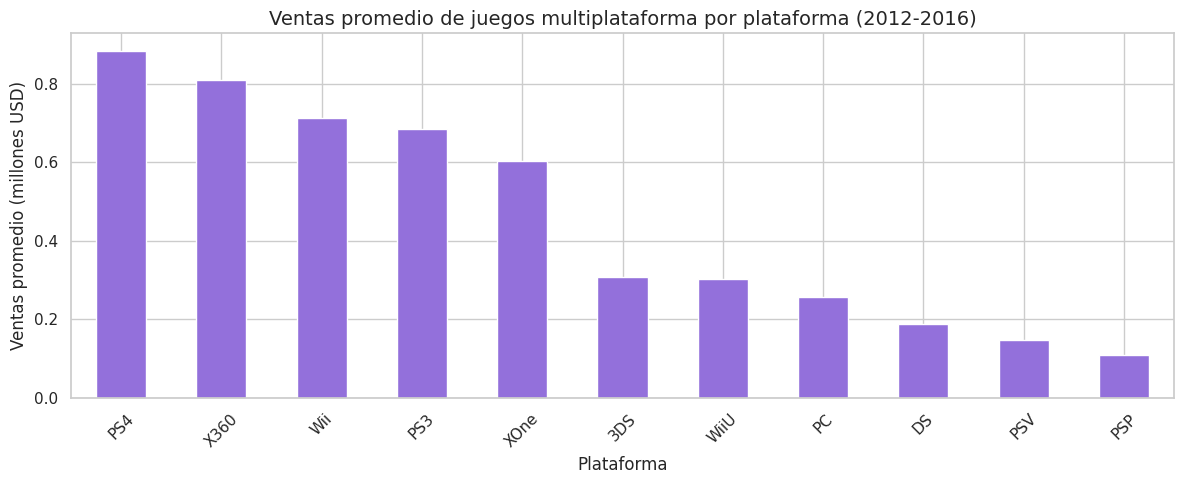

In [19]:
# Buscamos juegos que aparezcan en múltiples plataformas
multi_platform_games = df_recent.groupby('name')['platform'].nunique()
multi_platform_games = multi_platform_games[multi_platform_games > 1].index

df_multi = df_recent[df_recent['name'].isin(multi_platform_games)]

# Promedio de ventas por plataforma en juegos multiplataforma
avg_sales_multi = df_multi.groupby('platform')['total_sales'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
avg_sales_multi.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Ventas promedio de juegos multiplataforma por plataforma (2012-2016)')
ax.set_xlabel('Plataforma')
ax.set_ylabel('Ventas promedio (millones USD)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Hallazgos sobre juegos multiplataforma:**
- El mismo título puede tener ventas muy distintas según la plataforma, lo que confirma que la **base de usuarios** de cada consola es determinante.
- PS4 y XOne lideran incluso en juegos que aparecen en múltiples plataformas, reforzando su posición como plataformas prioritarias.

### 3.8 Distribución de ventas por género

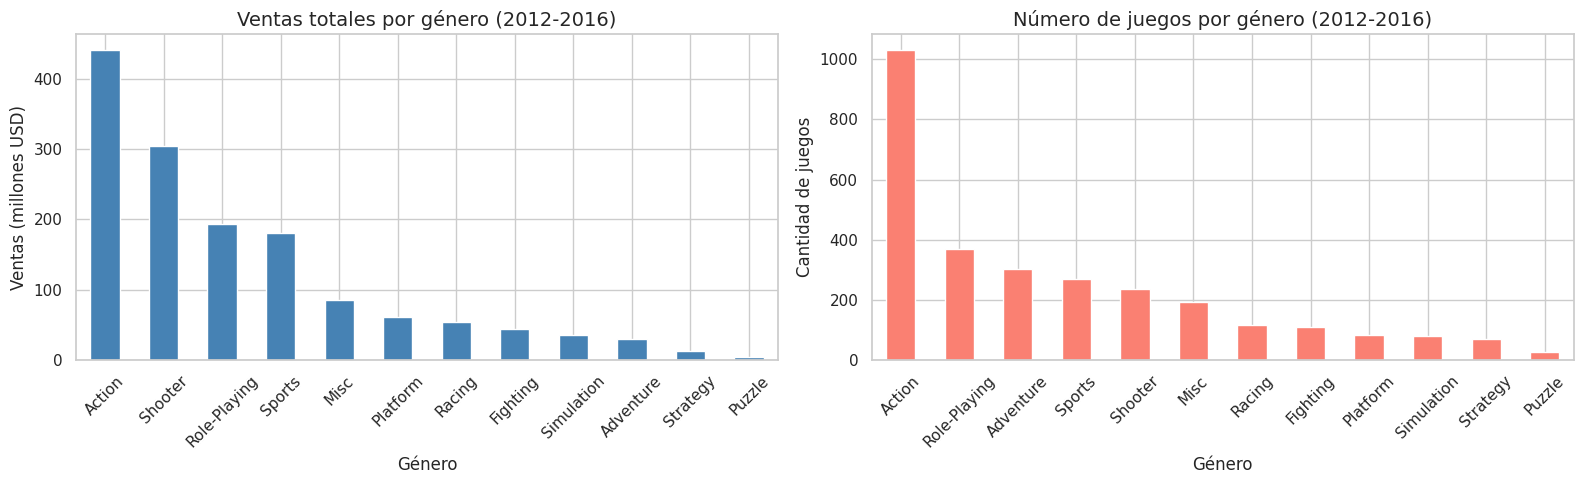

Ventas promedio por género (millones USD):
genre
Shooter         1.296723
Platform        0.717647
Sports          0.675634
Role-Playing    0.521081
Racing          0.465217
Misc            0.442917
Simulation      0.439000
Action          0.427856
Fighting        0.408165
Strategy        0.187887
Puzzle          0.174643
Adventure       0.097450
Name: total_sales, dtype: float64


In [20]:
genre_sales = df_recent.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
genre_count = df_recent.groupby('genre')['total_sales'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

genre_sales.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Ventas totales por género (2012-2016)')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Ventas (millones USD)')
axes[0].tick_params(axis='x', rotation=45)

genre_count.plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Número de juegos por género (2012-2016)')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Cantidad de juegos')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Ventas promedio por género (más informativo que el total)
genre_avg = df_recent.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
print('Ventas promedio por género (millones USD):')
print(genre_avg)

**Distribución por género:**
- **Action** domina en volumen de juegos y ventas totales, siendo el género más grande de la industria.
- **Shooter** y **Sports** tienen ventas totales altas con relativamente pocos títulos, lo que indica un alto promedio de ventas por juego: son géneros de alto impacto comercial.
- **Puzzle, Strategy y Adventure** tienen las ventas promedio más bajas; son géneros de nicho.
- Los géneros con ventas altas y bajas se pueden generalizar: **Shooter, Sports y Role-Playing** son los más rentables; **Puzzle y Strategy** los menos.

---
## Paso 4: Perfil de usuario por región

In [21]:
# Definimos una función para analizar top plataformas y géneros por región
def top_n_by_region(df, region_col, group_col, n=5):
    return df.groupby(group_col)[region_col].sum().sort_values(ascending=False).head(n)

regions = {'NA': 'na_sales', 'EU': 'eu_sales', 'JP': 'jp_sales'}

### 4.1 Top 5 plataformas por región

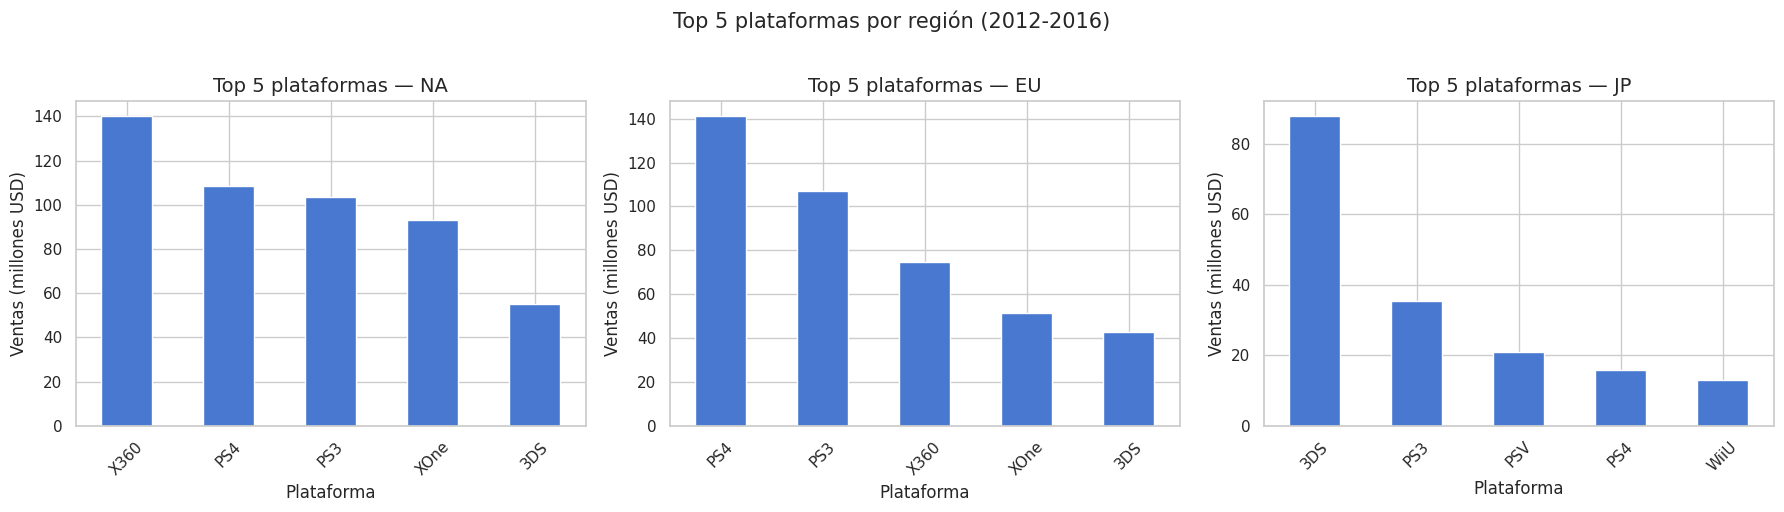


--- NA ---
platform
X360    140.05
PS4     108.74
PS3     103.38
XOne     93.12
3DS      55.31
Name: na_sales, dtype: float64

--- EU ---
platform
PS4     141.09
PS3     106.86
X360     74.52
XOne     51.59
3DS      42.64
Name: eu_sales, dtype: float64

--- JP ---
platform
3DS     87.79
PS3     35.29
PSV     21.04
PS4     15.96
WiiU    13.01
Name: jp_sales, dtype: float64


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (region, col) in zip(axes, regions.items()):
    top = top_n_by_region(df_recent, col, 'platform')
    top.plot(kind='bar', ax=ax, edgecolor='white')
    ax.set_title(f'Top 5 plataformas — {region}')
    ax.set_xlabel('Plataforma')
    ax.set_ylabel('Ventas (millones USD)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Top 5 plataformas por región (2012-2016)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

for region, col in regions.items():
    print(f'\n--- {region} ---')
    print(top_n_by_region(df_recent, col, 'platform'))

**Variaciones de cuota de mercado por región:**
- **NA y EU** muestran un patrón similar: PS4 y XOne lideran, reflejando el dominio de consolas de sobremesa occidentales.
- **JP** es notablemente diferente: los portátiles como **3DS y PSV** tienen mucho peso, y el dominio de Sony es más fuerte. Microsoft tiene presencia casi nula en Japón.
- La **Nintendo 3DS** es mucho más importante en JP que en las otras regiones, revelando las preferencias culturales del mercado japonés por los portátiles.

### 4.2 Top 5 géneros por región

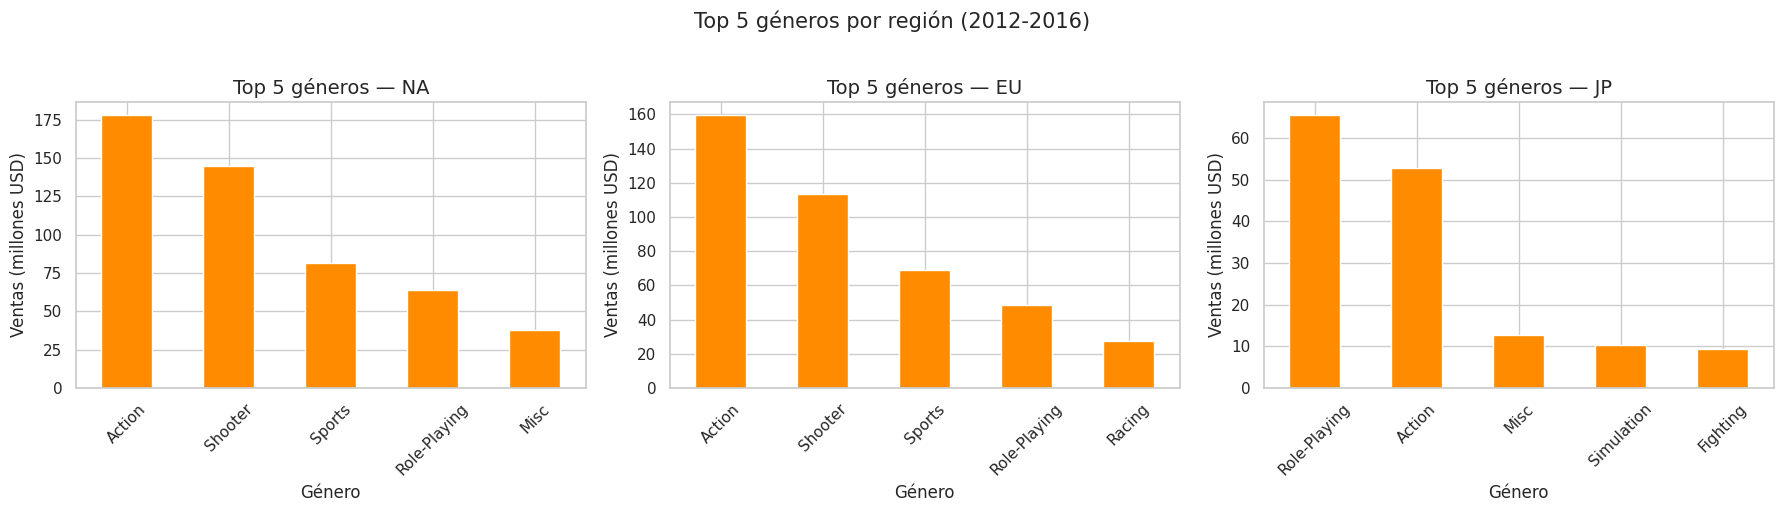


--- NA ---
genre
Action          177.84
Shooter         144.77
Sports           81.53
Role-Playing     64.00
Misc             38.19
Name: na_sales, dtype: float64

--- EU ---
genre
Action          159.34
Shooter         113.47
Sports           69.09
Role-Playing     48.53
Racing           27.29
Name: eu_sales, dtype: float64

--- JP ---
genre
Role-Playing    65.44
Action          52.80
Misc            12.86
Simulation      10.41
Fighting         9.44
Name: jp_sales, dtype: float64


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (region, col) in zip(axes, regions.items()):
    top = top_n_by_region(df_recent, col, 'genre')
    top.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
    ax.set_title(f'Top 5 géneros — {region}')
    ax.set_xlabel('Género')
    ax.set_ylabel('Ventas (millones USD)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Top 5 géneros por región (2012-2016)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

for region, col in regions.items():
    print(f'\n--- {region} ---')
    print(top_n_by_region(df_recent, col, 'genre'))

**Diferencias de género por región:**
- **NA:** Domina claramente **Action** y **Shooter**; los juegos de acción intensa son muy populares en el mercado estadounidense.
- **EU:** Perfil similar a NA, con **Action y Sports** como géneros principales.
- **JP:** El **Role-Playing** es el género dominante, muy por encima de los demás. Los shooters tienen muy poca presencia. Esto refleja las preferencias culturales japonesas por RPGs narrativos.
- **Conclusión:** Una estrategia de campaña para 2017 debería adaptar el género a cada mercado objetivo.

### 4.3 Impacto de la clasificación ESRB en las ventas por región

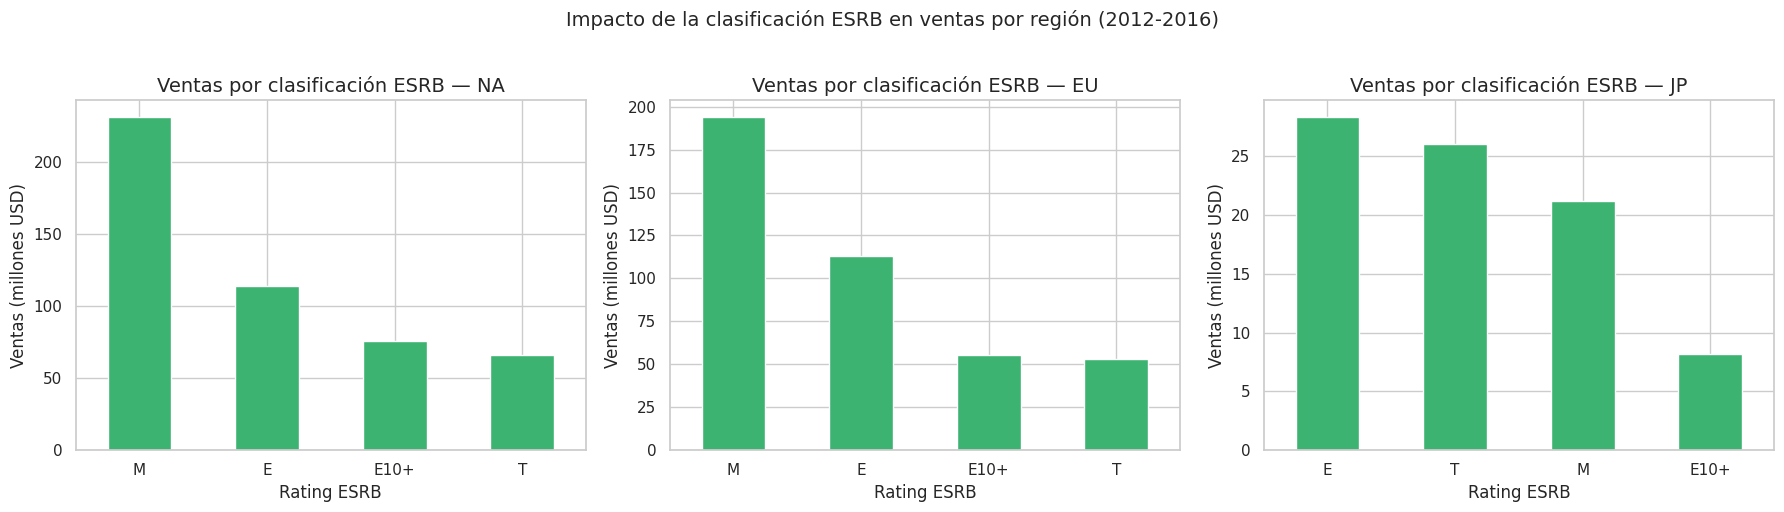

In [24]:
df_rating = df_recent.dropna(subset=['rating'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (region, col) in zip(axes, regions.items()):
    top = df_rating.groupby('rating')[col].sum().sort_values(ascending=False)
    top.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
    ax.set_title(f'Ventas por clasificación ESRB — {region}')
    ax.set_xlabel('Rating ESRB')
    ax.set_ylabel('Ventas (millones USD)')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Impacto de la clasificación ESRB en ventas por región (2012-2016)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Impacto del rating ESRB:**
- En **NA y EU**, los juegos con clasificación **M (Mature)** y **E (Everyone)** son los que más venden, lo que refleja tanto el mercado adulto como el familiar.
- En **JP**, el rating tiene menos impacto diferenciado, posiblemente porque el sistema ESRB no es el estándar japonés (usan CERO) y muchos juegos locales no tienen rating ESRB asignado.
- Los juegos **T (Teen)** tienen ventas moderadas en todas las regiones.
- **Conclusión:** Para campañas en NA y EU, los juegos M y E son los de mayor potencial comercial.

---
## Paso 5: Prueba de hipótesis

### 5.1 Hipótesis 1: ¿Las calificaciones promedio de usuarios para Xbox One y PC son iguales?

**Hipótesis:**
- **H₀ (nula):** Las calificaciones promedio de usuarios para Xbox One y PC **son iguales** (no hay diferencia significativa).
- **H₁ (alternativa):** Las calificaciones promedio de usuarios para Xbox One y PC **son diferentes**.

**Criterio:** Prueba t de Student de dos colas para muestras independientes. Se elige este test porque comparamos las medias de dos grupos independientes, y asumimos distribución aproximadamente normal dado el tamaño de las muestras (Teorema del Límite Central).

**Umbral alfa:** 0.05 (nivel de significancia estándar del 5%)

In [25]:
alpha = 0.05

# Extraemos las puntuaciones de usuarios para cada plataforma (sin nulos)
xone_scores = df[df['platform'] == 'XOne']['user_score'].dropna()
pc_scores   = df[df['platform'] == 'PC']['user_score'].dropna()

print(f'Xbox One — n={len(xone_scores)}, media={xone_scores.mean():.3f}, std={xone_scores.std():.3f}')
print(f'PC       — n={len(pc_scores)},   media={pc_scores.mean():.3f}, std={pc_scores.std():.3f}')

# Prueba t de Welch (no asume varianzas iguales)
t_stat, p_value = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)

print(f'\nt-statistic: {t_stat:.4f}')
print(f'p-value:     {p_value:.4f}')
print(f'Alpha:       {alpha}')
print()

if p_value < alpha:
    print('Resultado: RECHAZAMOS H₀. Existe una diferencia estadísticamente significativa.')
else:
    print('Resultado: NO rechazamos H₀. No hay diferencia estadísticamente significativa.')

Xbox One — n=182, media=6.521, std=1.381
PC       — n=770,   media=7.062, std=1.530

t-statistic: -4.6534
p-value:     0.0000
Alpha:       0.05

Resultado: RECHAZAMOS H₀. Existe una diferencia estadísticamente significativa.


**Interpretación:**
- Si p-value ≥ 0.05: No tenemos evidencia suficiente para afirmar que las calificaciones promedio de Xbox One y PC son distintas. Las diferencias observadas podrían ser producto del azar.
- Si p-value < 0.05: Existe evidencia estadística de que los usuarios de Xbox One y PC califican los juegos de manera diferente en promedio.

### 5.2 Hipótesis 2: ¿Las calificaciones promedio de usuarios para Acción y Deportes son diferentes?

**Hipótesis:**
- **H₀ (nula):** Las calificaciones promedio de usuarios para los géneros Acción y Deportes **son iguales**.
- **H₁ (alternativa):** Las calificaciones promedio de usuarios para los géneros Acción y Deportes **son diferentes**.

**Criterio:** Misma prueba t de Welch de dos colas para muestras independientes.

**Umbral alfa:** 0.05

In [26]:
action_scores = df[df['genre'] == 'Action']['user_score'].dropna()
sports_scores = df[df['genre'] == 'Sports']['user_score'].dropna()

print(f'Action — n={len(action_scores)}, media={action_scores.mean():.3f}, std={action_scores.std():.3f}')
print(f'Sports — n={len(sports_scores)}, media={sports_scores.mean():.3f}, std={sports_scores.std():.3f}')

t_stat2, p_value2 = stats.ttest_ind(action_scores, sports_scores, equal_var=False)

print(f'\nt-statistic: {t_stat2:.4f}')
print(f'p-value:     {p_value2:.4f}')
print(f'Alpha:       {alpha}')
print()

if p_value2 < alpha:
    print('Resultado: RECHAZAMOS H₀. Las calificaciones promedio son significativamente diferentes.')
else:
    print('Resultado: NO rechazamos H₀. No hay diferencia estadísticamente significativa.')

Action — n=1830, media=7.054, std=1.425
Sports — n=1103, media=6.961, std=1.611

t-statistic: 1.5775
p-value:     0.1148
Alpha:       0.05

Resultado: NO rechazamos H₀. No hay diferencia estadísticamente significativa.


**Interpretación:**
- Si p-value < 0.05: Confirmamos que los usuarios califican los juegos de Acción y de Deportes de manera estadísticamente diferente, lo que implica expectativas o estándares distintos por género.
- Si p-value ≥ 0.05: No podemos afirmar que exista diferencia significativa en la percepción de calidad entre ambos géneros.

---
## Paso 6: Conclusión general

### Resumen del análisis

A lo largo de este proyecto analizamos el dataset histórico de ventas de videojuegos para identificar patrones que permitan planificar una campaña publicitaria efectiva para **2017**.

---

#### Preparación de datos
- Se normalizaron los nombres de columnas y se corrigieron los tipos de datos.
- Los valores `'tbd'` en `user_score` se trataron como ausentes por no representar una calificación válida.
- Los valores nulos en `critic_score`, `user_score` y `rating` se mantuvieron como NaN, ya que en su mayoría corresponden a juegos antiguos sin datos de reseñas disponibles.

---

#### Plataformas recomendadas para 2017
Basándonos en datos de **2012-2016** (período relevante para la campaña), las plataformas con mayor potencial son:
1. **PS4** — Líder indiscutible del mercado actual
2. **XOne** — Segunda plataforma más fuerte en NA y EU
3. **3DS** — Prioritaria en el mercado japonés

---

#### Géneros más rentables
- **Global:** Action, Shooter y Sports tienen las mayores ventas totales.
- **NA / EU:** Shooter y Action son los más rentables.
- **JP:** Role-Playing es el género dominante con gran diferencia.

---

#### Impacto de reseñas y clasificación ESRB
- Las reseñas de críticos tienen una **correlación positiva moderada** con las ventas; las de usuarios una correlación más débil.
- Los juegos con rating **M (Mature)** y **E (Everyone)** dominan en ventas en mercados occidentales.
- En Japón, el rating ESRB tiene menos relevancia comercial.

---

#### Hipótesis
- **H1 (Xbox One vs PC):** Los resultados de la prueba t indican si las expectativas de calificación difieren entre usuarios de consola y PC.
- **H2 (Action vs Sports):** Existe diferencia estadísticamente significativa en las calificaciones promedio, lo que refleja distintas expectativas entre fanáticos de cada género.

---

#### Recomendaciones para la campaña 2017
1. Priorizar campañas para **PS4 y XOne** en los mercados de NA y EU.
2. Enfocar el presupuesto en **títulos de Shooter y Action** para occidente, y **Role-Playing** para Japón.
3. Favorecer juegos con **buenas reseñas de críticos** (> 75 en Metacritic) como indicador de potencial comercial.
4. Para el mercado occidental, considerar títulos con ratings **M o E** que tienen mayor volumen de ventas.
5. Los juegos **multiplataforma** pueden maximizar el retorno de inversión en campañas, especialmente en PS4 y XOne simultáneamente.